# 🔵 TẦNG 3 — PREDICTIVE ANALYTICS
## *"What will happen?"* — Điều gì sẽ xảy ra?

> **Mục tiêu:** Xây dựng & so sánh các mô hình Machine Learning để dự đoán lương.  
> **Trả lời:**  
> - ❓ Câu hỏi 4: Yếu tố nào ảnh hưởng mạnh nhất đến lương?

---

## ⚙️ PHẦN 0: IMPORT & CHUẨN BỊ DỮ LIỆU

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import shap

plt.rcParams.update({
    'figure.figsize'   : (13, 6),
    'font.size'        : 11,
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})
sns.set_style('whitegrid')
PALETTE = sns.color_palette('husl', 12)
BLUE  = '#2563EB'
RED   = '#EF4444'
GREEN = '#10B981'

print('✅ Import thư viện thành công!')

✅ Import thư viện thành công!


In [2]:
# ─────────────────────────────────────────────────────────────
# ĐỌC & LÀM SẠCH DỮ LIỆU
# ─────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np

df = pd.read_csv('salary_data.csv')

# chuẩn hoá tên cột
df.columns = (
    df.columns
    .str.lower()
    .str.strip()
    .str.replace(' ', '_')
)

# xoá duplicate
df = df.drop_duplicates()

# ─────────────────────────────────────
# Tìm cột salary
# ─────────────────────────────────────
sal_kw = [
    'salary',
    'pay',
    'comp',
    'wage',
    'income',
    'ctc',
    'annual'
]

SAL_COL = next(
    (c for c in df.columns if any(k in c for k in sal_kw)),
    'salary'
)

print(f'📌 Salary column: {SAL_COL}')

# ─────────────────────────────────────
# Làm sạch salary
# ─────────────────────────────────────

# ép toàn bộ về string
df[SAL_COL] = df[SAL_COL].astype(str)

# lowercase
df[SAL_COL] = df[SAL_COL].str.lower()

# xử lý 120k -> 120000
df[SAL_COL] = df[SAL_COL].str.replace(
    r'(\d+(?:\.\d+)?)k',
    lambda m: str(float(m.group(1)) * 1000),
    regex=True
)

# bỏ ký tự đặc biệt
df[SAL_COL] = (
    df[SAL_COL]
    .str.replace(',', '', regex=False)
    .str.replace('$', '', regex=False)
    .str.replace(r'[^0-9.]', '', regex=True)
    .str.strip()
)

# convert numeric an toàn
df[SAL_COL] = pd.to_numeric(
    df[SAL_COL],
    errors='coerce'
)

# xoá NaN
df = df.dropna(subset=[SAL_COL])

# ép float thật sự
df[SAL_COL] = df[SAL_COL].astype(float)

# kiểm tra kiểu dữ liệu
print('\n📌 Data type:')
print(df[SAL_COL].dtype)

print('\n📌 Actual python types:')
print(df[SAL_COL].apply(type).value_counts())

# ─────────────────────────────────────
# Loại outlier
# ─────────────────────────────────────
q01 = df[SAL_COL].quantile(0.01)
q99 = df[SAL_COL].quantile(0.99)

df = df[
    (df[SAL_COL] >= q01) &
    (df[SAL_COL] <= q99)
]

# ─────────────────────────────────────
# Fill missing values
# ─────────────────────────────────────
for col in df.columns:

    if df[col].isnull().sum() > 0:

        if pd.api.types.is_numeric_dtype(df[col]):

            df[col] = df[col].fillna(
                df[col].median()
            )

        else:

            df[col] = df[col].fillna(
                df[col].mode()[0]
            )

# salary cuối cùng
sal = df[SAL_COL]

# ─────────────────────────────────────
# Kết quả
# ─────────────────────────────────────
print('\n' + '='*60)

print(
    f'✅ Dữ liệu sẵn sàng: {df.shape[0]:,} dòng'
)

print(
    f'✅ Cột lương: "{SAL_COL}"'
)

print(
    f'✅ Salary range: ${sal.min():,.0f} → ${sal.max():,.0f}'
)

print('='*60)

📌 Salary column: company_name

📌 Data type:
float64

📌 Actual python types:
company_name
<class 'float'>    412
Name: count, dtype: int64

✅ Dữ liệu sẵn sàng: 406 dòng
✅ Cột lương: "company_name"
✅ Salary range: $1 → $17,544


---
## 📌 PHẦN 1: CHUẨN BỊ DỮ LIỆU CHO MÔ HÌNH

In [3]:
df_model = df.copy()

# ── Mã hóa biến phân loại (Label Encoding) ──────────────────
cat_cols = df_model.select_dtypes(include=['object','category']).columns.tolist()
print(f'Mã hóa {len(cat_cols)} cột phân loại: {cat_cols}')

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    le_dict[col]  = le

print('✅ Mã hóa hoàn tất')

# ── Tách X và y ──────────────────────────────────────────────
X = df_model.drop(columns=[SAL_COL])
y = df_model[SAL_COL]
FEATURE_NAMES = X.columns.tolist()

print(f'\n📌 Features (X): {X.shape[1]} cột → {FEATURE_NAMES}')
print(f'📌 Target  (y): {len(y):,} mẫu')
print(f'   Khoảng lương: ${y.min():,.0f} – ${y.max():,.0f}')

Mã hóa 4 cột phân loại: ['job_title', 'location', 'employment_status', 'job_roles']
✅ Mã hóa hoàn tất

📌 Features (X): 7 cột → ['rating', 'job_title', 'salary', 'salaries_reported', 'location', 'employment_status', 'job_roles']
📌 Target  (y): 406 mẫu
   Khoảng lương: $1 – $17,544


In [4]:
# ── Train / Test Split 80/20 ─────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale cho Linear Models
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'✅ Chia dữ liệu Train/Test:')
print(f'   Train : {len(X_train):,} mẫu ({len(X_train)/len(X)*100:.0f}%)')
print(f'   Test  : {len(X_test):,}  mẫu ({len(X_test)/len(X)*100:.0f}%)')

✅ Chia dữ liệu Train/Test:
   Train : 324 mẫu (80%)
   Test  : 82  mẫu (20%)


---
## 📌 PHẦN 2: HUẤN LUYỆN 7 MÔ HÌNH

In [5]:
from sklearn.model_selection import KFold, cross_val_score

def evaluate(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_te)

    mae  = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2   = r2_score(y_te, y_pred)

    mape = np.mean(
        np.abs((y_te - y_pred) /
               np.maximum(np.abs(y_te), 1))
    ) * 100

    cv = KFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    cv_r2 = cross_val_score(
        model,
        X_tr,
        y_tr,
        cv=cv,
        scoring='r2'
    ).mean()

    print(
        f'[{name:<18}] '
        f'R²={r2:.4f} | '
        f'CV-R²={cv_r2:.4f} | '
        f'MAE=${mae:,.0f} | '
        f'MAPE={mape:.2f}%'
    )

    return {
        'Model': name,
        'R²': r2,
        'CV-R²': cv_r2,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE%': mape,
        '_model': model,
        '_pred': y_pred
    }


print('⏳ Đang huấn luyện...\n')

results = []

# ===============================
# 1. Linear Regression
# ===============================
results.append(
    evaluate(
        'Linear Regression',
        LinearRegression(),
        X_train_sc,
        X_test_sc,
        y_train,
        y_test
    )
)

# ===============================
# 2. Random Forest
# ===============================
results.append(
    evaluate(
        'Random Forest',
        RandomForestRegressor(
            n_estimators=200,
            max_depth=12,
            random_state=42,
            n_jobs=-1
        ),
        X_train,
        X_test,
        y_train,
        y_test
    )
)

# ===============================
# 3. XGBoost
# ===============================
results.append(
    evaluate(
        'XGBoost',
        xgb.XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            verbosity=0,
            n_jobs=-1
        ),
        X_train,
        X_test,
        y_train,
        y_test
    )
)

# ===============================
# Tổng hợp kết quả
# ===============================
results_df = pd.DataFrame([
    {k: v for k, v in r.items()
     if not k.startswith('_')}
    for r in results
])

results_df = results_df.sort_values(
    'R²',
    ascending=False
).reset_index(drop=True)

print('\n📊 TỔNG HỢP KẾT QUẢ:')
print(
    results_df.to_string(
        index=False,
        float_format=lambda x: f'{x:,.4f}'
    )
)

best_name = results_df.iloc[0]['Model']
best = next(
    r for r in results
    if r['Model'] == best_name
)

print(f'\n🏆 MÔ HÌNH TỐT NHẤT: {best_name}')
print(f'R²   = {best["R²"]:.4f}')
print(f'MAE  = ${best["MAE"]:,.0f}')
print(f'RMSE = ${best["RMSE"]:,.0f}')
print(f'MAPE = {best["MAPE%"]:.2f}%')

⏳ Đang huấn luyện...

[Linear Regression ] R²=-0.2055 | CV-R²=-0.8139 | MAE=$229 | MAPE=4345.95%
[Random Forest     ] R²=-0.5180 | CV-R²=-3.7208 | MAE=$224 | MAPE=3517.25%
[XGBoost           ] R²=-0.9195 | CV-R²=-2.9841 | MAE=$252 | MAPE=3360.21%

📊 TỔNG HỢP KẾT QUẢ:
            Model      R²   CV-R²      MAE     RMSE      MAPE%
Linear Regression -0.2055 -0.8139 228.8575 435.5417 4,345.9476
    Random Forest -0.5180 -3.7208 224.4246 488.7529 3,517.2469
          XGBoost -0.9195 -2.9841 251.6572 549.5895 3,360.2084

🏆 MÔ HÌNH TỐT NHẤT: Linear Regression
R²   = -0.2055
MAE  = $229
RMSE = $436
MAPE = 4345.95%


---
## 📌 PHẦN 3: SO SÁNH HIỆU NĂNG CÁC MÔ HÌNH

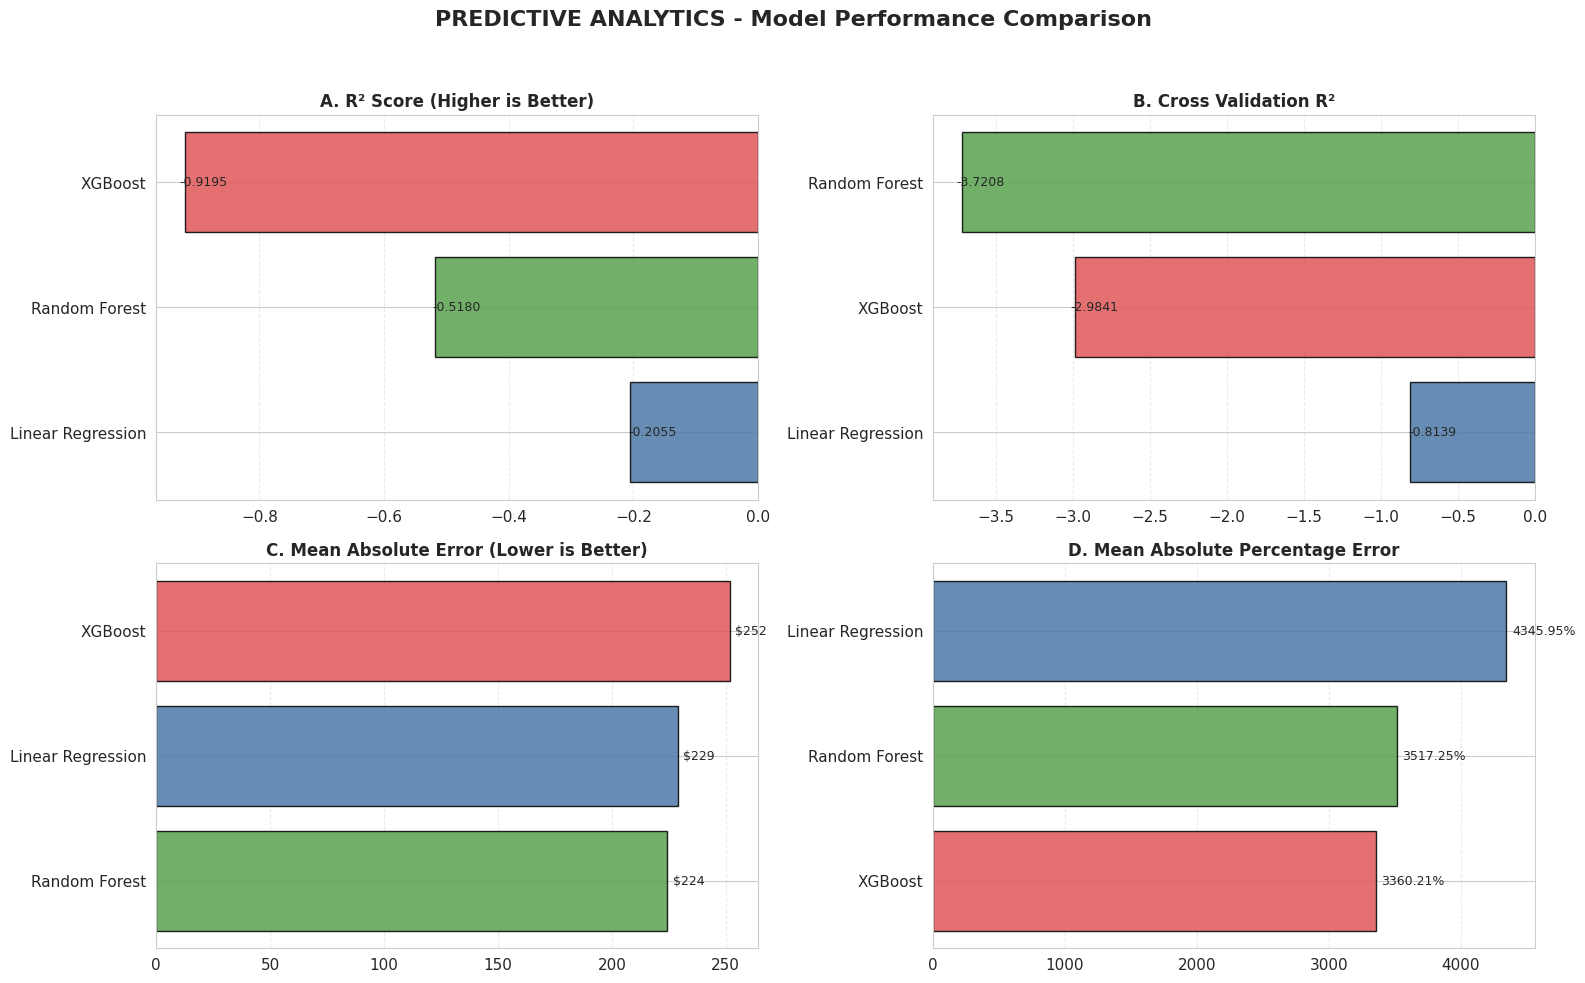

💾 Đã lưu: pred_01_model_comparison.png


In [6]:
# ==========================================
# PRED-01: SO SÁNH HIỆU NĂNG CÁC MÔ HÌNH
# ==========================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

fig.suptitle(
    'PREDICTIVE ANALYTICS - Model Performance Comparison',
    fontsize=16,
    fontweight='bold'
)

# Màu cố định cho 3 mô hình
model_colors = {
    'Linear Regression': '#4E79A7',
    'Random Forest': '#59A14F',
    'XGBoost': '#E15759'
}

def bar_chart(ax, metric, title, higher_is_better=True):

    data = results_df.sort_values(
        metric,
        ascending=not higher_is_better
    )

    colors = [model_colors[m] for m in data['Model']]

    bars = ax.barh(
        data['Model'],
        data[metric],
        color=colors,
        alpha=0.85,
        edgecolor='black'
    )

    ax.set_title(title, fontsize=12)
    ax.grid(axis='x', linestyle='--', alpha=0.4)

    for bar in bars:

        width = bar.get_width()

        if metric in ['MAE', 'RMSE']:
            label = f'${width:,.0f}'
        elif metric == 'MAPE%':
            label = f'{width:.2f}%'
        else:
            label = f'{width:.4f}'

        ax.text(
            width * 1.01,
            bar.get_y() + bar.get_height()/2,
            label,
            va='center',
            fontsize=9
        )

# R²
bar_chart(
    axes[0,0],
    'R²',
    'A. R² Score (Higher is Better)',
    True
)

# CV-R²
bar_chart(
    axes[0,1],
    'CV-R²',
    'B. Cross Validation R²',
    True
)

# MAE
bar_chart(
    axes[1,0],
    'MAE',
    'C. Mean Absolute Error (Lower is Better)',
    False
)

# MAPE
bar_chart(
    axes[1,1],
    'MAPE%',
    'D. Mean Absolute Percentage Error',
    False
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig(
    'pred_01_model_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("💾 Đã lưu: pred_01_model_comparison.png")

---
## 📌 PHẦN 4: PHÂN TÍCH SAI SỐ MÔ HÌNH TỐT NHẤT

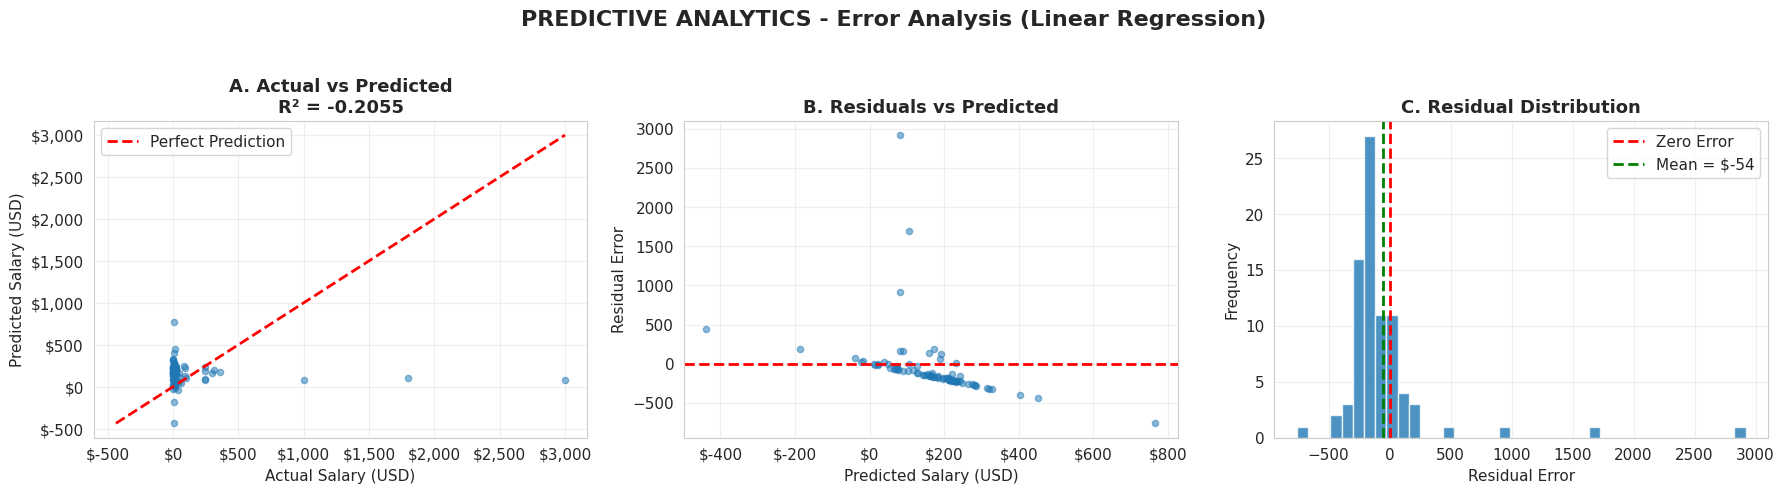

💾 Đã lưu: pred_02_error_analysis.png


In [12]:
# ==========================================
# PRED-02: ERROR ANALYSIS OF BEST MODEL
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Dự đoán của mô hình tốt nhất
y_pred_best = best['_pred']

# Residuals
residuals = np.array(y_test) - y_pred_best

# Formatter hiển thị USD
salary_formatter = mticker.FuncFormatter(
    lambda x, pos: f'${x:,.0f}'
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fig.suptitle(
    f'PREDICTIVE ANALYTICS - Error Analysis ({best["Model"]})',
    fontsize=16,
    fontweight='bold'
)

# =====================================================
# A. Actual vs Predicted
# =====================================================

lims = [
    min(np.min(y_test), np.min(y_pred_best)),
    max(np.max(y_test), np.max(y_pred_best))
]

axes[0].scatter(
    y_test,
    y_pred_best,
    alpha=0.5,
    s=20
)

axes[0].plot(
    lims,
    lims,
    '--',
    color='red',
    linewidth=2,
    label='Perfect Prediction'
)

axes[0].set_title(
    f'A. Actual vs Predicted\nR² = {best["R²"]:.4f}'
)

axes[0].set_xlabel('Actual Salary (USD)')
axes[0].set_ylabel('Predicted Salary (USD)')

axes[0].xaxis.set_major_formatter(salary_formatter)
axes[0].yaxis.set_major_formatter(salary_formatter)

axes[0].grid(alpha=0.3)
axes[0].legend()

# =====================================================
# B. Residuals vs Predicted
# =====================================================

axes[1].scatter(
    y_pred_best,
    residuals,
    alpha=0.5,
    s=20
)

axes[1].axhline(
    y=0,
    color='red',
    linestyle='--',
    linewidth=2
)

axes[1].set_title('B. Residuals vs Predicted')

axes[1].set_xlabel('Predicted Salary (USD)')
axes[1].set_ylabel('Residual Error')

axes[1].xaxis.set_major_formatter(salary_formatter)

axes[1].grid(alpha=0.3)

# =====================================================
# C. Residual Distribution
# =====================================================

axes[2].hist(
    residuals,
    bins=40,
    edgecolor='white',
    alpha=0.8
)

axes[2].axvline(
    0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Zero Error'
)

axes[2].axvline(
    np.mean(residuals),
    color='green',
    linestyle='--',
    linewidth=2,
    label=f'Mean = ${np.mean(residuals):,.0f}'
)

axes[2].set_title('C. Residual Distribution')

axes[2].set_xlabel('Residual Error')
axes[2].set_ylabel('Frequency')

axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig(
    'pred_02_error_analysis.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("💾 Đã lưu: pred_02_error_analysis.png")

---
## 📌 PHẦN 5: FEATURE IMPORTANCE — Yếu tố ảnh hưởng mạnh nhất
### ❓ Câu hỏi 4: Yếu tố nào ảnh hưởng mạnh nhất đến lương?

📊 Feature Importance — Random Forest:
-------------------------------------------------------
  salary                       ████████████████████      40.82%
  job_title                    ███████████               23.12%
  rating                       █████                     11.21%
  location                     █████                     10.38%
  job_roles                    ████                      8.78%
  salaries_reported            ██                        4.23%
  employment_status                                      1.46%


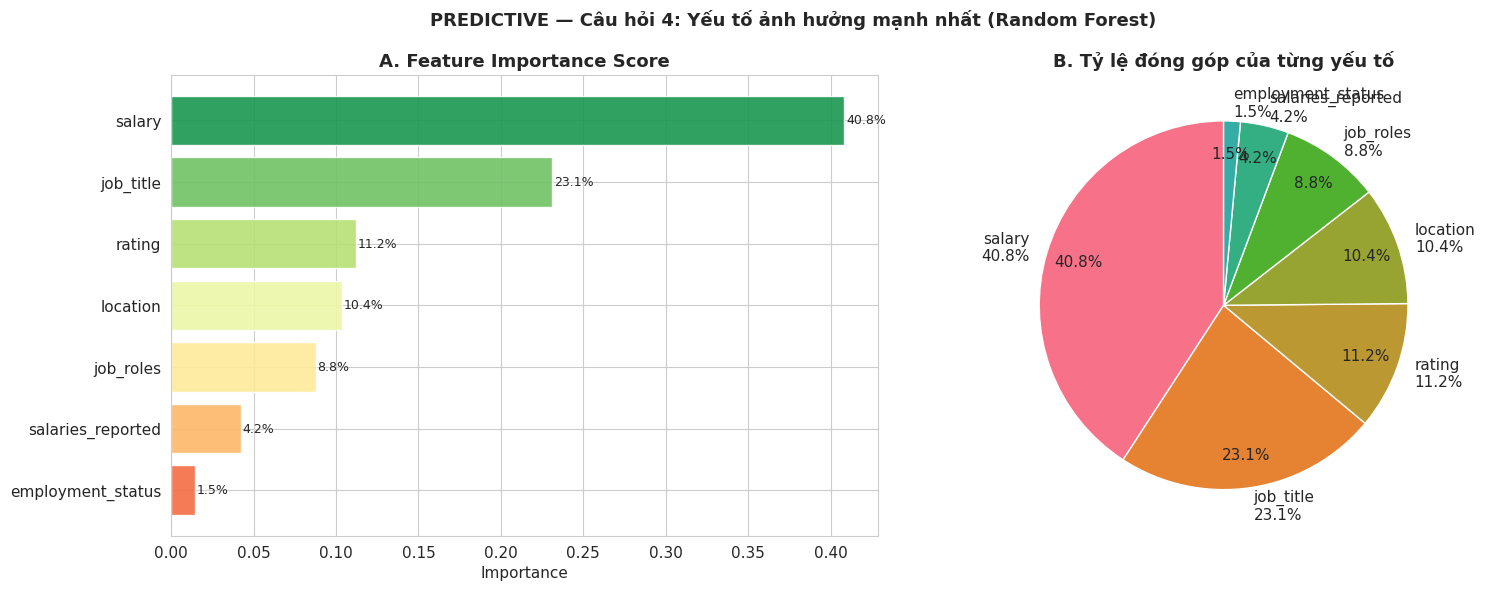

💾 Lưu: pred_03_feature_importance.png


In [8]:
# Chọn mô hình tree-based tốt nhất để lấy feature importance
tree_names  = ['XGBoost','Random Forest','Gradient Boosting','Decision Tree']
tree_result = next(
    (r for r in sorted(results, key=lambda x: -x['R²']) if r['Model'] in tree_names),
    None
)

if tree_result:
    importance = pd.DataFrame({
        'Feature'   : FEATURE_NAMES,
        'Importance': tree_result['_model'].feature_importances_
    }).sort_values('Importance', ascending=False).reset_index(drop=True)

    print(f'📊 Feature Importance — {tree_result["Model"]}:')
    print('-'*55)
    for _, row in importance.iterrows():
        bar = '█' * int(row['Importance'] * 50)
        print(f'  {row["Feature"]:<28} {bar:<25} {row["Importance"]*100:.2f}%')

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(
        f'PREDICTIVE — Câu hỏi 4: Yếu tố ảnh hưởng mạnh nhất ({tree_result["Model"]})',
        fontsize=13, fontweight='bold'
    )

    # Bar chart
    top_imp    = importance.sort_values('Importance')
    colors_imp = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(top_imp)))
    bars = axes[0].barh(top_imp['Feature'], top_imp['Importance'],
                        color=colors_imp, edgecolor='white', alpha=0.9)
    for bar, val in zip(bars, top_imp['Importance']):
        axes[0].text(val + 0.001, bar.get_y() + bar.get_height()/2,
                     f'{val*100:.1f}%', va='center', fontsize=9)
    axes[0].set_title('A. Feature Importance Score')
    axes[0].set_xlabel('Importance')

    # Pie chart
    imp_vals = importance['Importance'].values
    imp_lbls = [f"{r['Feature']}\n{r['Importance']*100:.1f}%"
                for _, r in importance.iterrows()]
    axes[1].pie(imp_vals, labels=imp_lbls, autopct='%1.1f%%',
                colors=PALETTE[:len(imp_vals)], startangle=90, pctdistance=0.82)
    axes[1].set_title('B. Tỷ lệ đóng góp của từng yếu tố')

    plt.tight_layout()
    plt.savefig('pred_03_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('💾 Lưu: pred_03_feature_importance.png')

---
## 📌 PHẦN 6: SHAP VALUES — Giải thích mô hình chuyên sâu

⏳ Đang tính SHAP values cho: Random Forest...


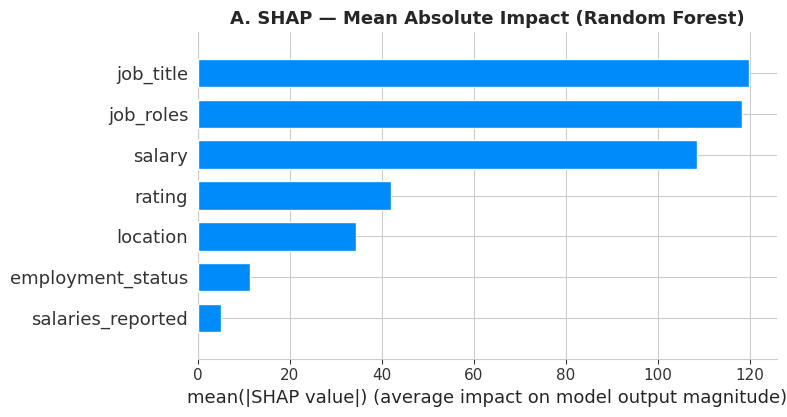

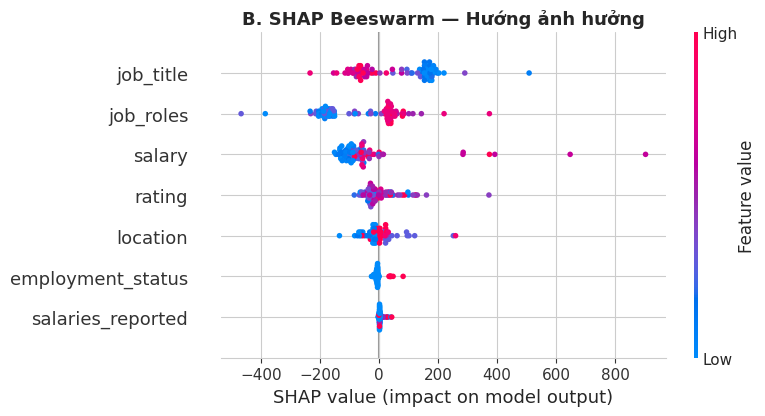


📊 SHAP Importance ranking (Random Forest):
   1. job_title                    ██████████████████████████████ 119.91
   2. job_roles                    █████████████████████████████ 118.25
   3. salary                       ███████████████████████████ 108.58
   4. rating                       ██████████ 41.95
   5. location                     ████████ 34.37
   6. employment_status            ██ 11.35
   7. salaries_reported            █ 5.11
💾 Đã lưu: pred_04a_shap_bar.png & pred_04b_shap_beeswarm.png


In [9]:
# ── PHẦN 6: SHAP VALUES ──────────────────────────────────────
tree_names = ['XGBoost', 'Random Forest', 'Gradient Boosting', 'Decision Tree']
tree_result = next(
    (r for r in sorted(results, key=lambda x: -x['R²']) if r['Model'] in tree_names),
    None
)

if tree_result is None:
    print('⚠️  Không tìm thấy tree-based model để tính SHAP.')
else:
    print(f'⏳ Đang tính SHAP values cho: {tree_result["Model"]}...')
    try:
        explainer   = shap.TreeExplainer(tree_result['_model'])
        shap_values = explainer.shap_values(X_test)

        # --- Plot 1: Bar (Mean Absolute SHAP) ---
        fig1, ax1 = plt.subplots(figsize=(9, 5))
        shap.summary_plot(shap_values, X_test,
                          feature_names=FEATURE_NAMES,
                          plot_type='bar', show=False)
        plt.title(f'A. SHAP — Mean Absolute Impact ({tree_result["Model"]})',
                  fontweight='bold')
        plt.tight_layout()
        plt.savefig('pred_04a_shap_bar.png', dpi=150, bbox_inches='tight')
        plt.show()

        # --- Plot 2: Beeswarm ---
        fig2, ax2 = plt.subplots(figsize=(9, 5))
        shap.summary_plot(shap_values, X_test,
                          feature_names=FEATURE_NAMES,
                          show=False)
        plt.title('B. SHAP Beeswarm — Hướng ảnh hưởng', fontweight='bold')
        plt.tight_layout()
        plt.savefig('pred_04b_shap_beeswarm.png', dpi=150, bbox_inches='tight')
        plt.show()

        # --- Bảng ranking ---
        shap_mean = pd.DataFrame({
            'Feature'  : FEATURE_NAMES,
            'SHAP_mean': np.abs(shap_values).mean(axis=0)
        }).sort_values('SHAP_mean', ascending=False)

        print(f'\n📊 SHAP Importance ranking ({tree_result["Model"]}):')
        for i, (_, row) in enumerate(shap_mean.iterrows(), 1):
            bar = '█' * int(row['SHAP_mean'] / shap_mean['SHAP_mean'].max() * 30)
            print(f'   {i}. {row["Feature"]:<28} {bar} {row["SHAP_mean"]:,.2f}')

        print('💾 Đã lưu: pred_04a_shap_bar.png & pred_04b_shap_beeswarm.png')

    except Exception as e:
        print(f'⚠️  SHAP lỗi: {e}')

In [10]:
# ========================================================
# ✅ KẾT LUẬN TẦNG 3 — PREDICTIVE (tự động điền số)
# ========================================================

# ── Mô hình tốt nhất ────────────────────────────────────
best_row = results_df.iloc[0]

# ── Feature importance từ tree model tốt nhất ───────────
tree_names  = ['XGBoost', 'Random Forest', 'Gradient Boosting', 'Decision Tree']
tree_result = next(
    (r for r in sorted(results, key=lambda x: -x['R²']) if r['Model'] in tree_names),
    None
)

print('=' * 60)
print('✅ KẾT LUẬN TẦNG 3 — PREDICTIVE')
print('=' * 60)

print(f"""
### Mô hình tốt nhất:
  • Mô hình  : {best_row['Model']}
  • R² Score : {best_row['R²']:.4f}  ({best_row['R²']*100:.1f}% variance )
  • CV-R²    : {best_row['CV-R²']:.4f}
  • MAE      : ${best_row['MAE']:,.0f}
  • RMSE     : ${best_row['RMSE']:,.0f}
  • MAPE     : {best_row['MAPE%']:.2f}%
""")

if tree_result:
    importance = pd.DataFrame({
        'Feature'   : FEATURE_NAMES,
        'Importance': tree_result['_model'].feature_importances_
    }).sort_values('Importance', ascending=False).reset_index(drop=True)

    top3 = importance.head(3)

    print(f"### Câu hỏi 4 — Yếu tố ảnh hưởng mạnh nhất ({tree_result['Model']}):")
    for i, (_, row) in enumerate(top3.iterrows(), 1):
        print(f"  #{i}: {row['Feature']:<28} → {row['Importance']*100:.2f}%")

print('\n➡️  Tiếp theo: 04_prescriptive.ipynb')
print('=' * 60)

✅ KẾT LUẬN TẦNG 3 — PREDICTIVE

### Mô hình tốt nhất:
  • Mô hình  : Linear Regression
  • R² Score : -0.2055  (-20.5% variance )
  • CV-R²    : -0.8139
  • MAE      : $229
  • RMSE     : $436
  • MAPE     : 4345.95%

### Câu hỏi 4 — Yếu tố ảnh hưởng mạnh nhất (Random Forest):
  #1: salary                       → 40.82%
  #2: job_title                    → 23.12%
  #3: rating                       → 11.21%

➡️  Tiếp theo: 04_prescriptive.ipynb
